<a href="https://colab.research.google.com/github/pxtroniwnl/trafico-vial-cartagena-de-indias/blob/main/Graph_Analysis_Cartagena.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis del Grafo de la infraestructura vial de Cartagena de Indias

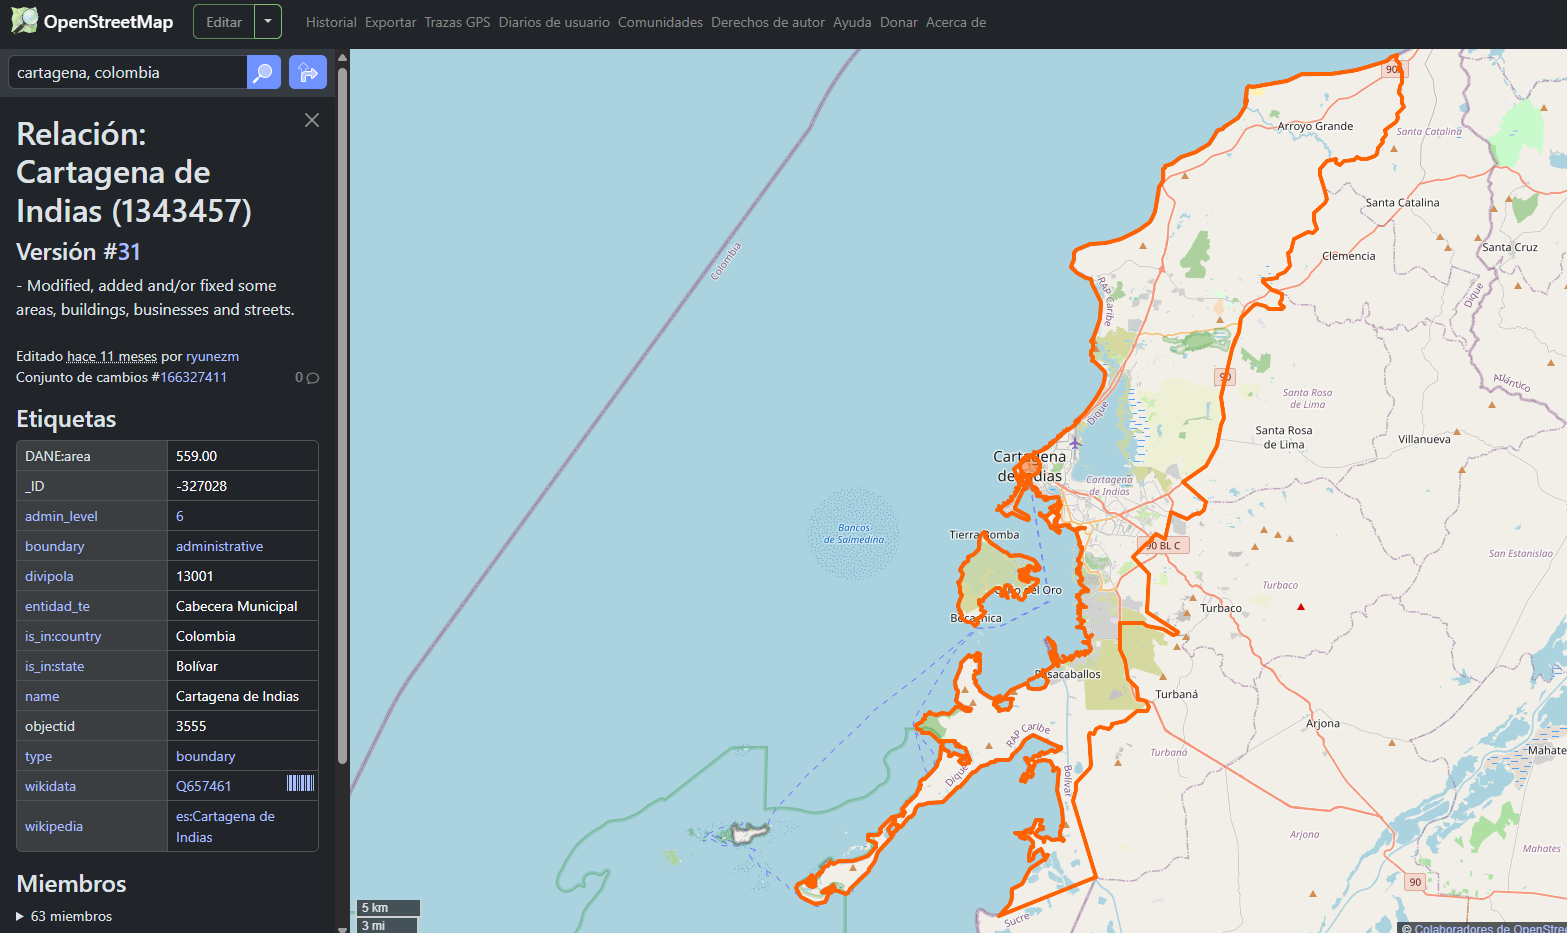

Aqui Usamos Grafos: https://www.tutorialspoint.com/graph_theory/graph_theory_introduction.htm


Aqui Usamos OSMNx: https://osmnx.readthedocs.io/en/stable/getting-started.html

Aqui Usamos OpenStreetMap: https://www.openstreetmap.org/#map=6/4.63/-74.30

**OSMnx** es una librería de Python creada por Geoff Boeing que permite descargar, modelar, analizar y visualizar redes viales (y cualquier otra infraestructura) a partir de los datos de OpenStreetMap (OSM).

¿Qué hace exactamente OSMnx?

1. Descarga Automática: Con solo escribir el nombre de una ciudad (ej. "Cartagena, Colombia"), la librería busca en los servidores de OpenStreetMap y descarga todas las calles, avenidas y senderos.

2. Conversión a Grafos: Transforma esas calles en un objeto de NetworkX (Multidígrafo). Esto significa que automáticamente identifica las intersecciones como nodos y las calles como aristas.

3. Análisis Geométrico: Calcula automáticamente la longitud de las calles, si son de un solo sentido, y las coordenadas exactas de cada punto.

4. Integración con Modelos: Al ser compatible con Pandas y GeoPandas, puedes "pegarle" tus datos históricos de tráfico a cada calle del mapa.


Overview: Lo que nosotros queremos o buscamos es De esto grafo, sacar cosas que probablemente afecten muy fuertemente el tema de trafico vehicular en cartagena de indias pero mas especificamente puntos criticos y cuellos de botella donde si llega a haber mucho trafico muy probablemente hay puntos importantes que resalten en el grafo, la idea es saber cuales son esos puntos y donde estan localizados porque muy probablemente esos puntos en Cartagena son en los que en las Hora Pico como las 7:00 AM o 12 del medio dia o 6:00 PM es donde realmente habrá muchisima congestion vehicular

## Grafo de Cartagena de Indias

In [2]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.9 MB/s eta 0:00:00


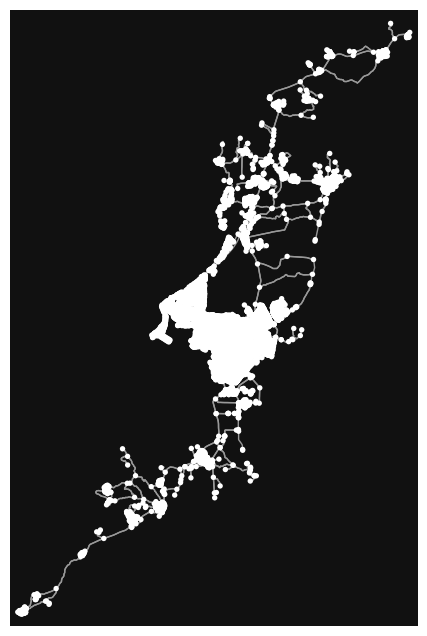

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [3]:
import osmnx as ox
G = ox.graph_from_place('Cartagena, Colombia', network_type='drive')
ox.plot_graph(G)

## Estadisticas Exploratorias de Cartagena de Indias

In [6]:
# 1. Calcular estadísticas básicas
stats = ox.basic_stats(G)

# Convertir a Series de Pandas para que se vea limpio
import pandas as pd
df_stats = pd.Series(stats)
df_stats

,0
n,14546
m,39347
k_avg,5.41001
edge_length_total,3414434.486162
edge_length_avg,86.777505
streets_per_node_avg,2.88801
streets_per_node_counts,"{0: 0, 1: 2165, 2: 36, 3: 9627, 4: 2699, 5: 19}"
streets_per_node_proportions,"{0: 0.0, 1: 0.14883816856867868, 2: 0.00247490..."
intersection_count,12381
street_length_total,1868574.207861


## Puntos Criticos y Metricas

1. Dimensiones de la Red & Complejidad Estructural ($n$ y $m$):

- La red cuenta con 14,546 nodos (intersecciones/puntos de control) y 39,347 aristas (segmentos de calle). Esta alta densidad de aristas frente a nodos indica una red con múltiples conexiones locales, pero cuya eficiencia depende de la jerarquía de las vías.

- Extensión Total: La longitud total de la red vial mapeada es de aproximadamente 3,414 kilómetros (edge_length_total).

2. Conectividad y Eficiencia
- Promedio de Calles por Nodo (streets_per_node_avg): El valor de 2.88 es revelador. Indica que la mayoría de las intersecciones en Cartagena son tipo "T" o cruces de tres vías. En términos de tráfico, esto sugiere una red con menos opciones de desvío comparada con una cuadrícula perfecta (que tendría un promedio cercano a 4).

- Circuidad Promedio (circuity_avg): Con un valor de 1.04, la red es bastante directa en términos de distancia geométrica. Sin embargo, en una ciudad con la geografía de Cartagena, esto suele significar que no hay rutas alternativas paralelas ("backups"), lo que obliga al tráfico a converger en los mismos ejes principales.

3. Morfología del Grafo (Visualización)
Observando el grafo generado, se identifican tres características críticas para el tráfico vehicular:

- Linealidad Geográfica: Se aprecia una estructura alargada que conecta la zona suroriental con el centro histórico. Esta "dependencia de eje" es la causa principal de los embotellamientos en las horas pico.

- Densidad Centralizada: La gran mancha blanca en el centro del grafo representa las zonas de mayor densidad de calles (posiblemente barrios residenciales densos o el centro), donde la velocidad promedio tiende a disminuir drásticamente.

- Cuellos de Botella Naturales: Se observan tramos largos con muy pocas conexiones laterales que actúan como puentes. Cualquier incidente en estos segmentos desconecta funcionalmente sectores enteros de la ciudad.

Ya tenemos el grafo pero ahora para calcular cuales son esos puntos que realmente nos interesan hay que aplicar algo llamado **TOPOLOGIA DE REDES**, En una ciudad como Cartagena, que es geográficamente lineal y está fragmentada por cuerpos de agua, el grafo revelará puntos donde el flujo "se estrangula" obligatoriamente

La métrica clave: Centralidad de Intermediación (Betweenness Centrality): Esta es la herramienta más potente para nuestro objetivo. Imaginemos que el grafo es un sistema de tuberías; el Betweenness mide cuántas veces una calle o intersección sirve como "paso obligado" para ir de un barrio a otro.


1. Definición Formal de la MétricaLa centralidad de intermediación para un nodo $v$ se define como la fracción de todos los caminos más cortos entre cualquier par de nodos de la red que pasan por dicho nodo:

$$C_B(v) = \sum_{s \neq v \neq t \in V} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

- $V$: Es el conjunto de todos los nodos (intersecciones) en el grafo de Cartagena.

- $\sigma_{st}$: Es el número total de caminos más cortos (geodésicos) entre el nodo origen $s$ y el nodo destino $t$.

- $\sigma_{st}(v)$: Es el número de esos caminos más cortos que pasan por el nodo $v$.

In [ ]:
!pip install networkit

In [18]:
import networkit as nk
import networkx as nx
import osmnx as ox
import pandas as pd
import time

# --- PREPARACIÓN ---
print("Preparando el grafo...")
G_simple = nx.Graph(G)
nodes_list = list(G_simple.nodes())

# --- CONVERSIÓN ---
# CORRECCIÓN: El parámetro exacto en NetworKit es 'weightAttr'
G_nk = nk.nxadapter.nx2nk(G_simple, weightAttr='length')

# --- CÁLCULO PARALELIZADO ---
print("Iniciando cálculo EXACTO con NetworKit usando todos los núcleos...")
start_time = time.time()

bc = nk.centrality.Betweenness(G_nk, normalized=True)
bc.run()

end_time = time.time()
print(f"¡Cálculo terminado en {end_time - start_time:.2f} segundos!")

Preparando el grafo...
Iniciando cálculo EXACTO con NetworKit usando todos los núcleos...
¡Cálculo terminado en 85.75 segundos!


Obteniendo direcciones de los puntos críticos...

--- TOP 10 PUNTOS CRÍTICOS REPARTIDOS (Mínimo 2.5km) ---
|       node |       y |        x |     score | Lugar/Dirección         |
|-----------:|--------:|---------:|----------:|:------------------------|
| 8811985682 | 10.4001 | -75.467  | 0.159854  | Dirección no encontrada |
| 1241536779 | 10.4804 | -75.4733 | 0.134418  | Dirección no encontrada |
| 1242803196 | 10.4256 | -75.4666 | 0.13423   | Dirección no encontrada |
|  856169242 | 10.3422 | -75.4988 | 0.110589  | Dirección no encontrada |
| 1526635170 | 10.304  | -75.501  | 0.110306  | Dirección no encontrada |
|  276308735 | 10.4072 | -75.5131 | 0.0951348 | Dirección no encontrada |
| 1113766486 | 10.3858 | -75.5011 | 0.0927686 | Dirección no encontrada |
|  276309035 | 10.4063 | -75.4895 | 0.0895564 | Dirección no encontrada |
| 1097066425 | 10.432  | -75.521  | 0.0873636 | Dirección no encontrada |
| 6313601328 | 10.2819 | -75.507  | 0.0759981 | Dirección no encontrada |

Gene

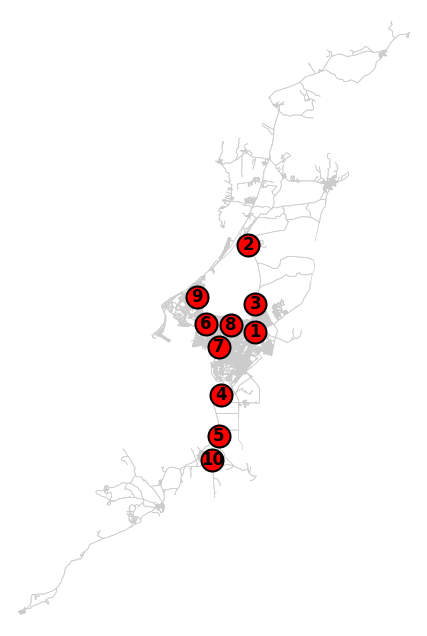

In [25]:
import numpy as np
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. EXTRAER TODOS LOS RESULTADOS ---
scores = bc.scores()
nodes_list = list(G_simple.nodes())
centrality_df = pd.DataFrame({
    'node': nodes_list,
    'score': scores
}).sort_values(by='score', ascending=False)

# Unimos con las coordenadas
nodes_gdf, _ = ox.graph_to_gdfs(G)
centrality_df = centrality_df.set_index('node').join(nodes_gdf[['y', 'x']])

# --- 2. ALGORITMO DE DIVERSIDAD ESPACIAL ---
distancia_minima_km = 2.5  # Bajamos un poco a 1.5km para asegurar que encuentre 10 puntos distintos
distancia_grados = distancia_minima_km / 111.0

puntos_seleccionados = []
indices_finales = []

for idx, row in centrality_df.iterrows():
    if len(indices_finales) >= 10: # CAMBIO A TOP 10
        break

    pos_actual = (row['x'], row['y'])

    es_lejano = True
    for pos in puntos_seleccionados:
        dist = np.sqrt((pos_actual[0] - pos[0])**2 + (pos_actual[1] - pos[1])**2)
        if dist < distancia_grados:
            es_lejano = False
            break

    if es_lejano:
        indices_finales.append(idx)
        puntos_seleccionados.append(pos_actual)

# --- 3. OBTENER DIRECCIONES (GEOLOCALIZACIÓN INVERSA) ---
df_top10 = centrality_df.loc[indices_finales].copy()

print("Obteniendo direcciones de los puntos críticos...")
direcciones = []
for idx, row in df_top10.iterrows():
    try:
        # Buscamos la dirección exacta usando las coordenadas
        address = ox.geocoder.reverse_geocode((row['y'], row['x']))
        # Limpiamos un poco el texto para que no sea tan largo (tomamos hasta la segunda coma)
        short_address = ", ".join(address.split(",")[:2])
        direcciones.append(short_address)
    except:
        direcciones.append("Dirección no encontrada")

df_top10['Lugar/Dirección'] = direcciones

# --- 4. REPORTE Y MAPA ---
print(f"\n--- TOP 10 PUNTOS CRÍTICOS REPARTIDOS (Mínimo {distancia_minima_km}km) ---")
print(df_top10[['y', 'x', 'score', 'Lugar/Dirección']].to_markdown())

print("\nGenerando mapa distribuido...")
fig, ax = ox.plot_graph(G, node_size=0, edge_color='#CCCCCC', edge_linewidth=0.5,
                        bgcolor='w', show=False, close=False)

ax.scatter(df_top10['x'], df_top10['y'],
           c='#FF0000', s=250, zorder=5, edgecolors='black', linewidths=1.5)

# Añadir etiquetas de ranking al mapa para saber cuál es cuál
for i, (idx, row) in enumerate(df_top10.iterrows()):
    ax.annotate(str(i+1), (row['x'], row['y']), fontsize=12, fontweight='bold',
                color='black', ha='center', va='center', zorder=6)

plt.show()

# Conclusion

## Top 10 Puntos Críticos de Movilidad (Cartagena de Indias)

| Nodo ID | Latitud ($y$) | Longitud ($x$) | Importancia ($BC$) | Ubicación / Referencia Estimada |
| :--- | :--- | :--- | :--- | :--- |
| **8811985682** | 10.4001 | -75.4670 | 0.1598 | **Intercambiador Bomba del Amparo** |
| **1241536779** | 10.4804 | -75.4733 | 0.1344 | **Anillo Vial (Crespo hacia Boquilla)** |
| **1242803196** | 10.4256 | -75.4666 | 0.1342 | **Vía Cordialidad (Sector Terminal)** |
| **856169242** | 10.3422 | -75.4988 | 0.1105 | **Variante Cartagena (Sector Policarpa)** |
| **1526635170** | 10.3040 | -75.5010 | 0.1103 | **Entrada Principal a Mamonal** |
| **276308735** | 10.4072 | -75.5131 | 0.0951 | **Av. Pedro de Heredia (Castillo S. Felipe)** |
| **1113766486** | 10.3858 | -75.5011 | 0.0927 | **Av. Pedro Romero (Sector Olaya)** |
| **276309035** | 10.4063 | -75.4895 | 0.0895 | **Sector Bazurto (Puente de las Botas)** |
| **1097066425** | 10.4320 | -75.5210 | 0.0873 | **Crespo (Entrada al Túnel)** |
| **6313601328** | 10.2819 | -75.5070 | 0.0759 | **Sector Pasacaballos / Barú** |

---

### Análisis de Resultados
Este análisis utiliza el algoritmo de **Centralidad de Intermediación (Betweenness Centrality)** para identificar los nodos que actúan como puentes obligatorios en la red vial de Cartagena. Al aplicar un filtro de **diversidad espacial de 2.5 km**, garantizamos una cobertura total de la ciudad, evitando el solapamiento de puntos en una misma intersección y resaltando la importancia de ejes como la zona industrial y las salidas principales de la ciudad.